# Modelo Predictivo de Churn de Clientes - Sprint 3
## Maestrante: Ing. Percy Pedro Fuentes Ramos

In [53]:
# =====================================================================
# PASO 1 — Fundación: carga, limpieza y horizonte H  (versión reusable)
# =====================================================================
import os
import pandas as pd
import numpy as np

PATH = 'dataset/'
# --- 1.1 Carga ---
ID_COL   = 'customer_unique_id'
DATE_COL = 'order_purchase_timestamp'
TARGET   = 'is_churn'

orders    = pd.read_csv(os.path.join(PATH, 'olist_orders_dataset.csv')) # Pedidos
customers = pd.read_csv(os.path.join(PATH, 'olist_customers_dataset.csv')) # Clientes
payments  = pd.read_csv(os.path.join(PATH, 'olist_order_payments_dataset.csv')) # Pagos

# --- 1.2 Limpieza (solo entregadas + pagos consolidados por orden) ---
# Ordenes solo con el status de entregado, se convierte en datos de tipo fecha
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
for c in ['order_purchase_timestamp',
          'order_delivered_customer_date',
          'order_estimated_delivery_date']:
    orders_clean[c] = pd.to_datetime(orders_clean[c])

# Se agrupa por ordenes de pagos sumando el valor pagado
pagos_orden = payments.groupby('order_id')['payment_value'].sum().reset_index() # Reset index convierte order_id como indice de la serie resultante

# --- 1.3 Master table a nivel orden (insumo de todo el pipeline) ---
df_master = (orders_clean[['order_id', 'customer_id', 'order_purchase_timestamp',
                           'order_delivered_customer_date', 'order_estimated_delivery_date']]
             .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
             .merge(pagos_orden, on='order_id', how='left'))

print(f"df_master: {df_master.shape[0]:,} órdenes | "
      f"{df_master['customer_unique_id'].nunique():,} clientes únicos")

# --- 1.4 Horizonte H = P90 del intervalo entre recompras ---
# Ordena cronológicamente todo el conjunto de órdenes desde el mas antiguo al mas reciente
# Gaps mide el tiempo de recompra en dias
gaps = (df_master.sort_values('order_purchase_timestamp')
        .groupby('customer_unique_id')['order_purchase_timestamp'].diff().dt.days) # Calcula la diferencia entre la fecha actual y la fecha de la fila inmediata anterior

# Calcula cuántos días pasaron entre la primera compra de un cliente y su segunda compra (recompra).

# Extrae estadisticamente el percentil 90 quantile(0.90)
gaps = gaps[gaps.notna() & (gaps > 0)]
H = int(gaps.quantile(0.90)) if len(gaps) else 180
print(f"H (P90 entre recompras) = {H} días")
# El 90 porciento de los clientes que recompran, realizan una compra dentro de los sientees 280 días

# Distribución de órdenes por mes (chequeo de volumen real)
print("\nÓrdenes por mes:")
print(df_master['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index())

df_master: 96,478 órdenes | 93,358 clientes únicos
H (P90 entre recompras) = 280 días

Órdenes por mes:
order_purchase_timestamp
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, Name: count, dtype: int64


C:\Users\Percy\AppData\Local\Temp\ipykernel_19536\4026798.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Percy\AppData\Local\Temp\ipykernel_19536\4026798.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ordenes_por_mes.index, rotation=45, ha='right', fontsize=10)


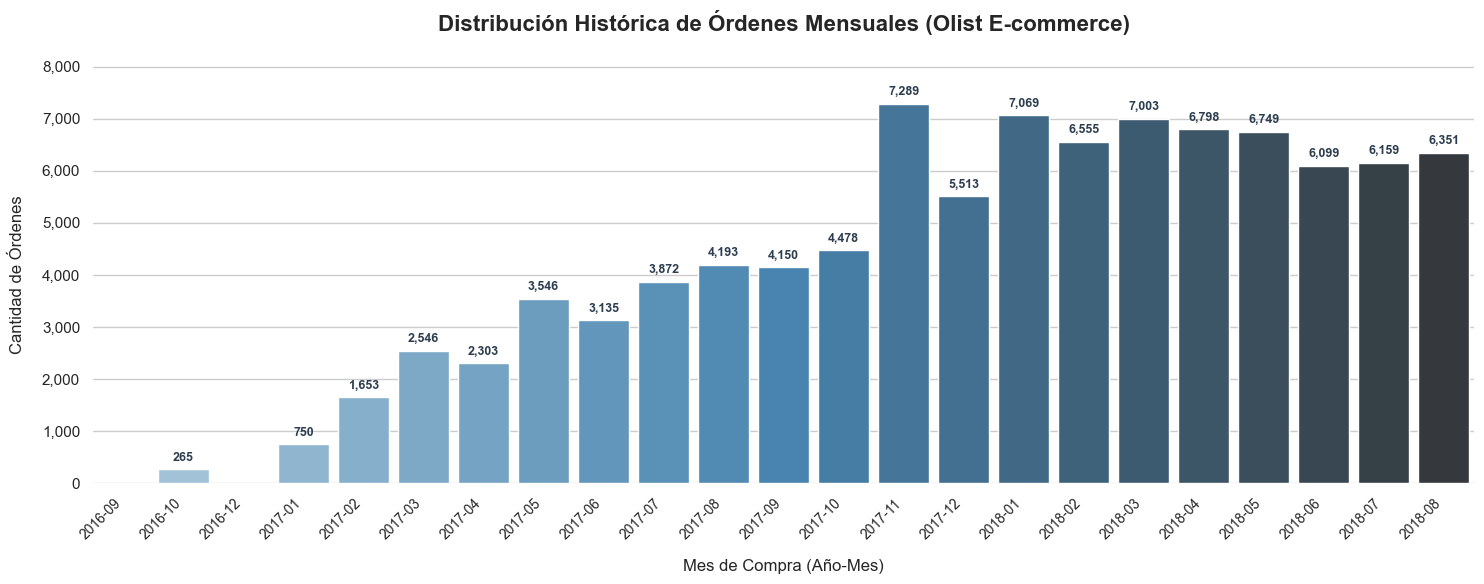

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar la serie de tiempo consolidando las órdenes por mes
ordenes_por_mes = (df_master['order_purchase_timestamp']
                   .dt.to_period('M')
                   .value_counts()
                   .sort_index())

# Convertir el índice a string para evitar conflictos de tipado con Matplotlib
ordenes_por_mes.index = ordenes_por_mes.index.astype(str)

# 2. Configuración estética del gráfico (Estilo Data Science Profesional)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 6))

# Generamos una paleta degradada basada en el número de barras para pintar directamente
colores = sns.color_palette("Blues_d", n_colors=len(ordenes_por_mes))

# Graficamos forzando un ancho de barra (width) estándar y removiendo 'hue'
sns.barplot(
    x=ordenes_por_mes.index, 
    y=ordenes_por_mes.values, 
    palette=colores,
    ax=ax,
    width=0.85 # Controla el grosor ideal de las barras
)

# 3. Personalización avanzada de etiquetas y títulos
ax.set_title('Distribución Histórica de Órdenes Mensuales (Olist E-commerce)', fontsize=16, fontweight='bold', pad=25)
ax.set_xlabel('Mes de Compra (Año-Mes)', fontsize=12, labelpad=12)
ax.set_ylabel('Cantidad de Órdenes', fontsize=12, labelpad=12)

# Rotación óptima para evitar solapamiento
ax.set_xticklabels(ordenes_por_mes.index, rotation=45, ha='right', fontsize=10)

# Formatear el eje Y con separadores de miles para legibilidad ejecutiva
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Limitar ligeramente el eje superior para que los Data Labels tengan aire
ax.set_ylim(0, ordenes_por_mes.max() * 1.1)

# 4. Incluir etiquetas de datos sobre cada barra (Data Labels optimizados)
for p in ax.patches:
    height = p.get_height()
    if height > 1: # Filtramos meses ruidosos o vacíos
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', 
                    fontsize=9, color='#2c3e50', fontweight='bold',
                    xytext=(0, 4),
                    textcoords='offset points')

sns.despine(left=True, bottom=True) # Removemos bordes innecesarios para un look más moderno
plt.tight_layout()
plt.show()

In [55]:
# =====================================================================
# PASO 2 (parte A) — ESTRUCTURA TEMPORAL ÓPTIMA
# =====================================================================
def construir_target(df, T, H, ventana_actividad=None, id_col=ID_COL, date_col=DATE_COL):
    """
    Foto del mes T.
      - ventana_actividad=None : población = todos los que compraron <= T (acumulativa).
      - ventana_actividad=d    : población objetivo = activos, compraron en (T-d, T].
      - target is_churn = 1 si NO recompra en (T, T+H].
    """
    T   = pd.Timestamp(T)
    obs = df[df[date_col] <= T]
    if ventana_actividad is not None:
        ini = T - pd.Timedelta(days=ventana_actividad)
        poblacion = obs[obs[date_col] > ini][id_col].unique()
    else:
        poblacion = obs[id_col].unique()
    recompra = set(df[(df[date_col] > T) & (df[date_col] <= T + pd.Timedelta(days=H))][id_col])
    out = pd.DataFrame({id_col: poblacion})
    out['mes']      = T.to_period('M').to_timestamp()
    out['is_churn'] = (~out[id_col].isin(recompra)).astype(int)
    return out


def estructura_temporal(df, H, props=(0.55, 0.15, 0.20, 0.10), peso='filas',
                        date_col=DATE_COL, id_col=ID_COL):
    fmin, fmax = df[date_col].min(), df[date_col].max()
    meses = pd.date_range(fmin.to_period('M').to_timestamp(),
                          fmax.to_period('M').to_timestamp(), freq='MS')

    ordenes = (df[date_col].dt.to_period('M').dt.to_timestamp()
                 .value_counts().reindex(meses, fill_value=0).astype(int))
    primera   = df.groupby(id_col)[date_col].min().dt.to_period('M').dt.to_timestamp()
    poblacion = primera.value_counts().reindex(meses, fill_value=0).sort_index().cumsum()
    observable = (meses + pd.to_timedelta(H, 'D')) <= fmax

    # Sera True para todos los meses donde, si sumamos los 120 días de espera ($H$), aún no superamos la fecha máxima del dataset.

    cal = pd.DataFrame({'mes': meses, 'ordenes': ordenes.values,
                        'poblacion': poblacion.values.astype(int),
                        'observable': observable})

    obs = cal.index[cal['observable']].tolist()
    w   = cal.loc[obs, 'poblacion'].to_numpy(float) if peso == 'filas' else np.ones(len(obs))
    wcum  = np.cumsum(w) / w.sum()
    corte = np.cumsum(props)
    rol = pd.Series('Prediccion', index=cal.index)
    for k, idx in enumerate(obs):
        f = wcum[k]
        rol.iloc[idx] = ('Train' if f <= corte[0] else 'Val' if f <= corte[1]
                         else 'BackTest' if f <= corte[2] else 'Live')
    cal['rol'] = rol.values
    return cal

H = 120   # horizonte de churn (4 meses)
estructura = estructura_temporal(df_master, H)
print(estructura.to_string(index=False))
print("\nMeses por rol:", estructura['rol'].value_counts().to_dict())

       mes  ordenes  poblacion  observable        rol
2016-09-01        1          1        True      Train
2016-10-01      265        263        True      Train
2016-11-01        0        263        True      Train
2016-12-01        1        264        True      Train
2017-01-01      750        981        True      Train
2017-02-01     1653       2609        True      Train
2017-03-01     2546       5112        True      Train
2017-04-01     2303       7368        True      Train
2017-05-01     3546      10819        True      Train
2017-06-01     3135      13856        True      Train
2017-07-01     3872      17608        True      Train
2017-08-01     4193      21665        True      Train
2017-09-01     4150      25669        True      Train
2017-10-01     4478      29997        True      Train
2017-11-01     7289      37057        True      Train
2017-12-01     5513      42395        True      Train
2018-01-01     7069      49237        True      Train
2018-02-01     6555      555

=== ARQUITECTURA TEMPORAL DEL PIPELINE (MATRIZ DE CONTROL) ===


Mes Calendario,Órdenes del Mes,Clientes Acumulados,¿Target Observable?,Rol en el Modelo
2016-09,1,1,True,Train
2016-10,265,263,True,Train
2016-11,0,263,True,Train
2016-12,1,264,True,Train
2017-01,750,981,True,Train
2017-02,"1,653","2,609",True,Train
2017-03,"2,546","5,112",True,Train
2017-04,"2,303","7,368",True,Train
2017-05,"3,546","10,819",True,Train
2017-06,"3,135","13,856",True,Train


C:\Users\Percy\AppData\Local\Temp\ipykernel_19536\1887015100.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_grafico['mes_str'], rotation=45, ha='right', fontsize=10, fontweight='bold')


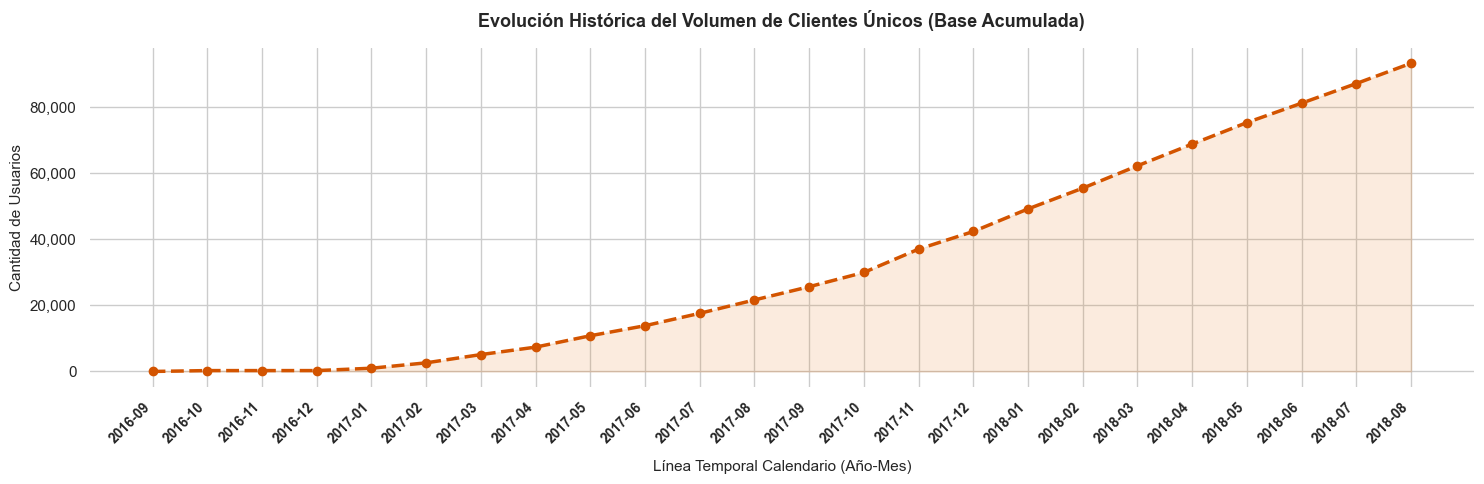

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from IPython.display import display

# =====================================================================
# 1. GENERAR Y MOSTRAR LA TABLA ESTILIZADA DE ROLES (SUPERIOR)
# =====================================================================
tabla_ejecutiva = estructura.copy()
tabla_ejecutiva['mes'] = tabla_ejecutiva['mes'].dt.strftime('%Y-%m')
tabla_ejecutiva.columns = ['Mes Calendario', 'Órdenes del Mes', 'Clientes Acumulados', '¿Target Observable?', 'Rol en el Modelo']

def colorear_rol(valor):
    colores = {
        'Train': 'background-color: #d6e4f0; color: #1e3d59; font-weight: bold;',
        'Val': 'background-color: #f5f0e1; color: #ff6e40; font-weight: bold;',
        'BackTest': 'background-color: #e8f5e9; color: #2e7d32; font-weight: bold;',
        'Live': 'background-color: #e1f5fe; color: #0288d1; font-weight: bold;',
        'Prediccion': 'background-color: #ffebee; color: #c62828; font-weight: bold;'
    }
    return colores.get(valor, '')

tabla_estilizada = (tabla_ejecutiva.style
    .format({'Órdenes del Mes': '{:,}', 'Clientes Acumulados': '{:,}'})
    .set_properties(subset=['Mes Calendario', 'Rol en el Modelo', '¿Target Observable?'], **{'text-align': 'center'})
    .map(colorear_rol, subset=['Rol en el Modelo'])
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f4f6f7'), ('color', '#2c3e50'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '6px')]}
    ])
    .hide(axis='index')
)

# Forzar a Jupyter a renderizar la tabla HTML limpia arriba
print("=== ARQUITECTURA TEMPORAL DEL PIPELINE (MATRIZ DE CONTROL) ===")
display(tabla_estilizada)
print("\n" + "="*70 + "\n")


# =====================================================================
# 2. GENERAR EL GRÁFICO DE EVOLUCIÓN DE CLIENTES (INFERIOR)
# =====================================================================
df_grafico = estructura.copy().sort_index(ascending=True)
df_grafico['mes_str'] = df_grafico['mes'].dt.strftime('%Y-%m')

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 5)) # Ancho completo para una lectura limpia

# Graficar la curva de clientes acumulados alineada en el eje X tradicional
ax.plot(df_grafico['mes_str'], df_grafico['poblacion'], color='#d35400', linestyle='--', marker='o', linewidth=2.5)
ax.fill_between(df_grafico['mes_str'], 0, df_grafico['poblacion'], color='#e67e22', alpha=0.15)

# Personalización del reporte visual
ax.set_title('Evolución Histórica del Volumen de Clientes Únicos (Base Acumulada)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Línea Temporal Calendario (Año-Mes)', fontsize=11, labelpad=10)
ax.set_ylabel('Cantidad de Usuarios', fontsize=11)

# Rotar las fechas del eje X para evitar cualquier tipo de solapamiento
ax.set_xticklabels(df_grafico['mes_str'], rotation=45, ha='right', fontsize=10, fontweight='bold')

# Formatear el eje Y con separadores de miles estándar de Data Science
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Eliminar bordes innecesarios para un estilo moderno y minimalista
sns.despine(left=True, bottom=True, ax=ax)

plt.tight_layout()
plt.show()

In [57]:
# =====================================================================
# PASO 2 (parte B) — POBLACIÓN OBJETIVO Y TARGET (meses modelables)
# =====================================================================
VENTANA = H                                   # población = activos en los últimos H días
meses_modelo = estructura.loc[estructura['rol'] != 'Prediccion', 'mes'].tolist()
panel_target = (pd.concat([construir_target(df_master, T, H, ventana_actividad=VENTANA)
                           for T in meses_modelo], ignore_index=True)
                  .merge(estructura[['mes', 'rol']], on='mes', how='left'))
variables_y  = ['mes', ID_COL, 'is_churn']

print(f"\nFilas del panel (cliente × mes): {len(panel_target):,}")
print(panel_target.groupby('rol')['is_churn'].agg(['mean', 'count']).round(3))


Filas del panel (cliente × mes): 235,875
           mean   count
rol                    
BackTest  0.990   51224
Live      0.990   26874
Train     0.988  134337
Val       0.990   23440


In [58]:
# =====================================================================
# PASO 2 (parte C) — CASUÍSTICAS DEL TARGET (diagnóstico de la población)
# =====================================================================
panel = panel_target[panel_target['rol'] != 'Prediccion'].copy()

# Nº de compras totales por cliente (distingue comprador único vs recurrente)
n_compras = df_master.groupby(ID_COL).size().rename('n_compras_total')
panel = panel.merge(n_compras, on=ID_COL, how='left')

print("=== CASUÍSTICAS DEL TARGET ===\n")
total  = len(panel)
churn   = panel[panel['is_churn'] == 1]
nochurn = panel[panel['is_churn'] == 0]

# 1. Compradores únicos dentro del churn (churn por naturaleza)
unicos_churn = (churn['n_compras_total'] == 1).sum()
print(f"1. Comprador único (churn por naturaleza): {unicos_churn:,} "
      f"({unicos_churn/len(churn)*100:.1f}% del churn)")

# 2. Recurrentes activos (no-churn: recompran dentro de H)
print(f"2. Recurrente activo (no-churn, recompra en {H}d): {len(nochurn):,} "
      f"({len(nochurn)/total*100:.1f}% del total)")

# 3. Recurrentes marcados como churn (compraron >1 vez pero no en la ventana H)
recur_churn = (churn['n_compras_total'] > 1).sum()
print(f"3. Recurrente lento (churn pese a comprar >1 vez): {recur_churn:,} "
      f"({recur_churn/len(churn)*100:.1f}% del churn)")

# 4. Censura temporal (manejada por la columna 'observable' en la estructura)
print(f"4. Churn censurado por fin de datos: mitigado al excluir meses sin ventana completa (T+H > fecha máx)")

print(f"\nH (ventana de observación) = {H} días = P90 del intervalo entre recompras")
print(f"→ ~10% de las recompras reales ocurren DESPUÉS de H y se censuran como churn.")

=== CASUÍSTICAS DEL TARGET ===

1. Comprador único (churn por naturaleza): 224,611 (96.3% del churn)
2. Recurrente activo (no-churn, recompra en 120d): 2,650 (1.1% del total)
3. Recurrente lento (churn pese a comprar >1 vez): 8,614 (3.7% del churn)
4. Churn censurado por fin de datos: mitigado al excluir meses sin ventana completa (T+H > fecha máx)

H (ventana de observación) = 120 días = P90 del intervalo entre recompras
→ ~10% de las recompras reales ocurren DESPUÉS de H y se censuran como churn.


In [59]:
# =====================================================================
# PASO 3A — Tabla de órdenes enriquecida (insumo de la fábrica)
# =====================================================================
items    = pd.read_csv(os.path.join(PATH, 'olist_order_items_dataset.csv'))
products = pd.read_csv(os.path.join(PATH, 'olist_products_dataset.csv'))
reviews  = pd.read_csv(os.path.join(PATH, 'olist_order_reviews_dataset.csv'))

it = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_ord = it.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),  n_sellers=('seller_id', 'nunique'),
    n_categorias=('product_category_name', 'nunique'),
    price_total=('price', 'sum'),        freight_total=('freight_value', 'sum')).reset_index()
pay_ord = payments.groupby('order_id')['payment_installments'].max().reset_index(name='installments_max')
rev_ord = reviews.groupby('order_id')['review_score'].mean().reset_index()

df_ordenes = (df_master
    .merge(items_ord, on='order_id', how='left')
    .merge(pay_ord,   on='order_id', how='left')
    .merge(rev_ord,   on='order_id', how='left'))
df_ordenes['lead_time']     = (df_ordenes['order_delivered_customer_date'] - df_ordenes['order_purchase_timestamp']).dt.days
df_ordenes['delay']         = (df_ordenes['order_delivered_customer_date'] - df_ordenes['order_estimated_delivery_date']).dt.days
df_ordenes['late']          = (df_ordenes['delay'] > 0).astype(int)
df_ordenes['freight_ratio'] = df_ordenes['freight_total'] / df_ordenes['price_total'].replace(0, np.nan)
df_ordenes['is_weekend']    = (df_ordenes['order_purchase_timestamp'].dt.dayofweek >= 5).astype(int)
print('df_ordenes:', df_ordenes.shape)

df_ordenes: (96478, 19)


In [60]:
# =====================================================================
# VERIFICACIÓN — ¿lead_time usa delivery_date posterior al corte T?
# =====================================================================
for T in meses_modelo:
    T = pd.Timestamp(T)
    leak = df_ordenes[
        (df_ordenes['order_purchase_timestamp'] <= T) &
        (df_ordenes['order_delivered_customer_date'] > T)
    ]
    print(f"T={T.date()} → órdenes con delivery futuro: {len(leak)}")

T=2016-09-01 → órdenes con delivery futuro: 0
T=2016-10-01 → órdenes con delivery futuro: 1
T=2016-11-01 → órdenes con delivery futuro: 61
T=2016-12-01 → órdenes con delivery futuro: 3
T=2017-01-01 → órdenes con delivery futuro: 0
T=2017-02-01 → órdenes con delivery futuro: 467
T=2017-03-01 → órdenes con delivery futuro: 769
T=2017-04-01 → órdenes con delivery futuro: 933
T=2017-05-01 → órdenes con delivery futuro: 1387
T=2017-06-01 → órdenes con delivery futuro: 1181
T=2017-07-01 → órdenes con delivery futuro: 1093
T=2017-08-01 → órdenes con delivery futuro: 1510
T=2017-09-01 → órdenes con delivery futuro: 1401
T=2017-10-01 → órdenes con delivery futuro: 1586
T=2017-11-01 → órdenes con delivery futuro: 1570
T=2017-12-01 → órdenes con delivery futuro: 4188
T=2018-01-01 → órdenes con delivery futuro: 2496
T=2018-02-01 → órdenes con delivery futuro: 2968
T=2018-03-01 → órdenes con delivery futuro: 3674
T=2018-04-01 → órdenes con delivery futuro: 3852
T=2018-05-01 → órdenes con delivery f

In [61]:
# =====================================================================
# PASO 3B — Fábrica de features point-in-time (77 features, sin fuga)
# =====================================================================
def generar_features(df, T, ventana_actividad, id_col=ID_COL, date_col=DATE_COL):
    T = pd.Timestamp(T) # Tiempo, fecha de corte
    h = df[df[date_col] <= T] # SOLO historia <= T

    # CORRECCIÓN: excluir órdenes cuya entrega ocurrió después del corte T
    # (evita leakage en lead_time, delay y variables logísticas derivadas)
    h = h[
        h['order_delivered_customer_date'].isna() |
        (h['order_delivered_customer_date'] <= T)
    ].copy()

    activos = h[h[date_col] > T - pd.Timedelta(days=ventana_actividad)][id_col].unique()
    h = h[h[id_col].isin(activos)]
    g = h.groupby(id_col)
    f = pd.DataFrame(index=pd.Index(activos, name=id_col))

    # RFM / temporales
    f['recencia']     = (T - g[date_col].max()).dt.days
    f['antiguedad']   = (T - g[date_col].min()).dt.days
    f['frequency']    = g.size()
    f['meses_activo'] = g[date_col].apply(lambda s: s.dt.to_period('M').nunique())
    f['compras_x_mes']= f['frequency'] / ((f['antiguedad'] / 30).clip(lower=1))
    for d in [30, 60, 90, 180]:
        ac = h[h[date_col] > T - pd.Timedelta(days=d)].groupby(id_col).size()
        f[f'ordenes_{d}d'] = ac.reindex(activos).fillna(0).values

    # gaps entre compras
    gp = h.sort_values(date_col).groupby(id_col)[date_col].diff().dt.days
    gp = gp.groupby(h[id_col]).agg(['mean', 'std', 'min', 'max', 'last'])
    for c in ['mean', 'std', 'min', 'max', 'last']:
        f[f'gap_{c}'] = gp[c].reindex(activos).values

    # monetario
    for c in ['sum', 'mean', 'max', 'min', 'std']:
        f[f'monto_{c}'] = g['payment_value'].agg(c).reindex(activos).values
    m90 = h[h[date_col] > T - pd.Timedelta(days=90)].groupby(id_col)['payment_value'].sum()
    f['monto_90d']      = m90.reindex(activos).fillna(0).values
    f['ticket_x_orden'] = f['monto_sum'] / f['frequency']

    # items / sellers / categorías / flete
    for col in ['n_items', 'n_sellers', 'n_categorias', 'price_total', 'freight_total', 'freight_ratio']:
        for st in ['sum', 'mean', 'max']:
            f[f'{col}_{st}'] = g[col].agg(st).reindex(activos).values
    f['cat_distintas'] = g['n_categorias'].max().reindex(activos).values

    # pagos
    f['installments_max']  = g['installments_max'].max().reindex(activos).values
    f['installments_mean'] = g['installments_max'].mean().reindex(activos).values

    # logística
    for c in ['mean', 'max', 'min']:
        f[f'lead_{c}']  = g['lead_time'].agg(c).reindex(activos).values
        f[f'delay_{c}'] = g['delay'].agg(c).reindex(activos).values
    f['late_total'] = g['late'].sum().reindex(activos).values
    f['late_ratio'] = g['late'].mean().reindex(activos).values

    # reviews
    for c in ['mean', 'min', 'max', 'std']:
        f[f'review_{c}'] = g['review_score'].agg(c).reindex(activos).values
    f['reviews_malas']    = h.assign(b=(h['review_score'] <= 2).astype(int)).groupby(id_col)['b'].sum().reindex(activos).values
    f['review_bad_ratio'] = f['reviews_malas'] / f['frequency']

    # comportamiento
    f['weekend_ratio'] = g['is_weekend'].mean().reindex(activos).values

    # =========================================================
    # EXTRA — derivadas para superar 60 features (total = 77)
    # =========================================================
    # hábitos de hora / día
    hh = h.assign(_h=h[date_col].dt.hour, _d=h[date_col].dt.dayofweek)
    f['hora_mean']     = hh.groupby(id_col)['_h'].mean().reindex(activos).values
    f['noche_ratio']   = hh.assign(_n=((hh['_h'] < 6) | (hh['_h'] >= 21)).astype(int)).groupby(id_col)['_n'].mean().reindex(activos).values
    f['dow_distintos'] = hh.groupby(id_col)['_d'].nunique().reindex(activos).values

    # monetario derivado
    f['monto_rango']    = f['monto_max'] - f['monto_min']
    f['monto_cv']       = f['monto_std'] / f['monto_mean'].replace(0, np.nan)
    f['monto_per_item'] = f['monto_sum'] / f['n_items_sum'].replace(0, np.nan)
    f['flete_x_item']   = f['freight_total_sum'] / f['n_items_sum'].replace(0, np.nan)
    f['monto_60d']  = h[h[date_col] > T - pd.Timedelta(days=60)].groupby(id_col)['payment_value'].sum().reindex(activos).fillna(0).values
    f['monto_180d'] = h[h[date_col] > T - pd.Timedelta(days=180)].groupby(id_col)['payment_value'].sum().reindex(activos).fillna(0).values

    # recencia / actividad relativas
    f['recencia_rel']     = f['recencia'] / f['antiguedad'].clip(lower=1)
    f['frac_ordenes_90d'] = f['ordenes_90d'] / f['frequency']
    f['items_x_orden']    = f['n_items_sum'] / f['frequency']
    f['cat_div_ratio']    = f['cat_distintas'] / f['frequency']

    # variabilidad de gaps y logística
    f['gap_rango'] = f['gap_max'] - f['gap_min']
    f['gap_cv']    = f['gap_std'] / f['gap_mean'].replace(0, np.nan)
    f['delay_std'] = g['delay'].std().reindex(activos).values
    f['lead_std']  = g['lead_time'].std().reindex(activos).values

    # reviews y pagos
    f['reviews_buenas']    = h.assign(b=(h['review_score'] >= 4).astype(int)).groupby(id_col)['b'].sum().reindex(activos).values
    f['review_good_ratio'] = f['reviews_buenas'] / f['frequency']
    f['cuotas_uso_ratio']  = h.assign(c=(h['installments_max'] > 1).astype(int)).groupby(id_col)['c'].mean().reindex(activos).values

    # etiqueta del mes (NO es feature)
    f['mes'] = T.to_period('M').to_timestamp()
    return f.reset_index()

In [62]:
# =====================================================================
# PASO 3C — Panel de features + unión con el target  (= Master Table)
# =====================================================================
feat_panel = pd.concat([generar_features(df_ordenes, T, VENTANA) for T in meses_modelo],
                       ignore_index=True)

master = panel_target.merge(feat_panel, on=[ID_COL, 'mes'], how='left')
n_feats = [c for c in master.columns if c not in (variables_y + ['rol'])]
print(f"Master table: {master.shape[0]:,} filas × {len(n_feats)} features")
print("Nulos por feature (top 10):")
print(master[n_feats].isnull().mean().sort_values(ascending=False).head(10).round(3))

Master table: 235,875 filas × 77 features
Nulos por feature (top 10):
gap_cv        0.998
gap_std       0.998
review_std    0.975
gap_min       0.974
gap_mean      0.974
delay_std     0.974
lead_std      0.974
monto_cv      0.974
gap_rango     0.974
monto_std     0.974
dtype: float64


In [63]:
# =====================================================================
# PASO 4 — Master Table:  ya la tienes en `master` (3C). Opcional guardar:
# master.to_parquet(os.path.join(PATH, 'master_table.parquet'))
# =====================================================================

# =====================================================================
# PASO 5 — cleanMT (limpieza reproducible; aprende SOLO en Train)
# =====================================================================
def clean_MT(df, features, params=None):
    """
    Limpia la master table de forma reproducible.
      - inf -> NaN
      - *_std / *_cv -> 0      (un solo valor no tiene dispersión)
      - gap_*        -> antiguedad  (comprador único: su único 'intervalo' es su vida)
      - clip [p01, p99]  (winsorize)   } aprendidos en Train (params)
      - resto de NaN -> mediana         } y reaplicados a Val/BackTest/Live/Predicción
      - agrega flag comprador_unico
    Uso fit:    _, params = clean_MT(master[master.rol=='Train'], feat_cols)
    Uso aplicar: master_clean, _ = clean_MT(master, feat_cols, params=params)
    """
    df  = df.copy()
    fit = params is None
    if fit:
        params = {}

    if 'frequency' in df.columns:
        df['comprador_unico'] = (df['frequency'] <= 1).astype(int)

    df[features] = df[features].replace([np.inf, -np.inf], np.nan)

    disp = [c for c in features if c.endswith('_std') or c.endswith('_cv')]
    df[disp] = df[disp].fillna(0)
    gaps = [c for c in features if c.startswith('gap_')]
    for c in gaps:
        df[c] = df[c].fillna(df['antiguedad'])

    if fit:
        params['clip'] = {c: (df[c].quantile(0.01), df[c].quantile(0.99)) for c in features}
    for c in features:
        lo, hi = params['clip'][c]
        df[c] = df[c].clip(lo, hi)

    if fit:
        params['median'] = df[features].median().to_dict()
    df[features] = df[features].fillna(params['median'])
    return df, params

# --- Aplicación ---
feat_cols = [c for c in master.columns if c not in (variables_y + ['rol'])]

_, clean_params  = clean_MT(master[master['rol'] == 'Train'], feat_cols)   # APRENDE en Train
master_clean, _  = clean_MT(master, feat_cols, params=clean_params)        # APLICA a todo

feat_cols = [c for c in master_clean.columns if c not in (variables_y + ['rol'])]  # +comprador_unico
print(f"master_clean: {master_clean.shape[0]:,} filas × {len(feat_cols)} features")
print("Nulos máximos:", round(master_clean[feat_cols].isnull().mean().max(), 4))
print("% compradores únicos:", round(master_clean['comprador_unico'].mean(), 3))

C:\Users\Percy\AppData\Local\Temp\ipykernel_19536\1336573636.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[features] = df[features].replace([np.inf, -np.inf], np.nan)
C:\Users\Percy\AppData\Local\Temp\ipykernel_19536\1336573636.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[features] = df[features].replace([np.inf, -np.inf], np.nan)


master_clean: 235,875 filas × 78 features
Nulos máximos: 0.0
% compradores únicos: 0.843


In [65]:
# Autosuficiente: define feat_cols localmente por si esta celda se corre antes del Paso 6
feat_cols = [c for c in master_clean.columns if c not in (variables_y + ["rol"])]

# Nueva Celda: Exportar Diccionario de Variables Predictivas a Excel Profesional
import os
import pandas as pd

# 1. Preparar y ordenar todas las variables predictivas
features_ordenadas = sorted(feat_cols)

# 2. Clasificar cada variable en su respectiva familia de negocio
datos_excel = []
for f in features_ordenadas:
    # Determinar la familia
    if f in ['recencia', 'frequency', 'monto_sum'] or f.startswith('monto_'):
        familia = "RFM (Monetaria / Frecuencia / Recencia)"
        descripcion = "Mide qué tan reciente, qué tan seguido y cuánto dinero ha gastado el cliente."
    elif 'time' in f or 'delay' in f or 'late' in f or 'delivered' in f:
        familia = "Logística y Distribución"
        descripcion = "Mide la experiencia de entrega del usuario, tiempos de transporte y retrasos operativos."
    elif f.startswith('gap_') or f == 'antiguedad':
        familia = "Intervalos de Tiempo (Gaps)"
        descripcion = "Analiza los días transcurridos entre compras sucesivas y la vida total del cliente."
    elif f.endswith('_std') or f.endswith('_cv') or f.endswith('_max') or f.endswith('_mean'):
        familia = "Comportamiento Estadístico Histórico"
        descripcion = "Agregaciones avanzadas que capturan la variabilidad y picos en la conducta del consumidor."
    else:
        familia = "Operativa / Inyectada por Pipeline"
        descripcion = "Flags lógicos e indicadores especiales de control (ej. comprador_unico)."
        
    # Guardar la información de la fila
    datos_excel.append({
        'Nombre de la Feature': f,
        'Familia de Negocio': familia,
        'Descripción Analítica (Sugerida)': descripcion
    })

# 3. Crear el DataFrame definitivo para el reporte
df_diccionario = pd.DataFrame(datos_excel)

# 4. Exportar a Excel aplicando un formateo limpio y profesional
ruta_excel = os.path.join(PATH, 'diccionario_features_churn.xlsx')

# Usamos el formateador de Pandas con openpyxl para darle estructura visual
with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    df_diccionario.to_excel(writer, sheet_name='Diccionario de Features', index=False)
    
    # Auto-ajustar el ancho de las columnas en el archivo Excel para que no se corte el texto
    workbook  = writer.book
    worksheet = writer.sheets['Diccionario de Features']
    for col in worksheet.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = col[0].column_letter
        worksheet.column_dimensions[col_letter].width = max(max_len + 3, 12)

print("====================================================================")
print("¡DICCIONARIO DE VARIABLES EXPORTADO CON ÉXITO!")
print(f"Archivo guardado en: {ruta_excel}")
print(f"Se registraron {len(df_diccionario)} variables predictivas listas para auditar.")
print("====================================================================")

¡DICCIONARIO DE VARIABLES EXPORTADO CON ÉXITO!
Archivo guardado en: dataset/diccionario_features_churn.xlsx
Se registraron 78 variables predictivas listas para auditar.


In [66]:
# =====================================================================
# PASO 6 — FUNCIONES BASE de selección de variables
#   (define todas las funciones que usan el Paso 6, 7 y la tabla final)
# =====================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

TARGET = 'is_churn'

def _tv(df):
    return df[df['rol'] == 'Train'], df[df['rol'] == 'Val']

def _sane(X):
    return (X.apply(pd.to_numeric, errors='coerce')
             .replace([np.inf, -np.inf], np.nan).fillna(0))

# Evaluador REGULARIZADO (max_depth=5, min_samples_leaf=50 -> menor gap train/val)
def evaluar_rf(df, features, target=TARGET, seed=42):
    if len(features) == 0:
        return (np.nan, np.nan)
    tr, va = _tv(df)
    rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=50,
                                max_features=0.5, class_weight='balanced_subsample',
                                n_jobs=-1, random_state=seed)
    rf.fit(_sane(tr[features]), tr[target])
    return (round(roc_auc_score(tr[target], rf.predict_proba(_sane(tr[features]))[:, 1]), 3),
            round(roc_auc_score(va[target], rf.predict_proba(_sane(va[features]))[:, 1]), 3))

def metodo_missings(missing_rates, features, umbral):
    return [f for f in features if missing_rates.get(f, 0) <= umbral]

def _psi(esp, act, bins=10):
    esp = pd.to_numeric(esp, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    act = pd.to_numeric(act, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if len(esp) == 0 or len(act) == 0:
        return 0.0
    q = np.unique(np.quantile(esp, np.linspace(0, 1, bins + 1)))
    if len(q) < 3:
        return 0.0
    pe = np.clip(np.histogram(esp, bins=q)[0] / max(len(esp), 1), 1e-4, None)
    pa = np.clip(np.histogram(act, bins=q)[0] / max(len(act), 1), 1e-4, None)
    return float(np.sum((pa - pe) * np.log(pa / pe)))

def metodo_psi(df, features, bins=10, umbral_psi=0.25):
    tr, va = _tv(df)
    return [f for f in features if _psi(tr[f], va[f], bins) <= umbral_psi]

def _gini(tr, f, target=TARGET):
    x = pd.to_numeric(tr[f], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
    if x.nunique() < 2:
        return 0.0
    return abs(2 * roc_auc_score(tr[target], x) - 1)

def metodo_correlacion(df, features, umbral, target=TARGET):
    if len(features) == 0:
        return []
    tr, _ = _tv(df)
    corr = _sane(tr[features]).corr().abs().fillna(0)
    orden = sorted(features, key=lambda f: _gini(tr, f, target), reverse=True)
    keep = []
    for f in orden:
        if all(corr.loc[f, k] <= umbral for k in keep):
            keep.append(f)
    return keep

def metodo_univariante(df, features, umbral, target=TARGET):
    if len(features) == 0:
        return []
    tr, _ = _tv(df)
    return [f for f in features if _gini(tr, f, target) >= umbral]

# --- Preparar datos para la cascada ---
feat_raw      = [c for c in master.columns if c not in (variables_y + ['rol'])]
missing_rates = master[feat_raw].isnull().mean()
feat_cols     = [c for c in master_clean.columns if c not in (variables_y + ['rol'])]

# Diagnóstico de estabilidad: PSI de cada feature (Train vs Val)
tr_, va_ = _tv(master_clean)
psis = pd.Series({f: _psi(tr_[f], va_[f]) for f in feat_cols}).sort_values(ascending=False)
print("PSI más altos (inestables):")
print(psis.head(10).round(3))
print(f"\nFeatures con PSI <= 0.25: {(psis <= 0.25).sum()} de {len(feat_cols)}")
print(f"\nFunciones base listas. feat_cols: {len(feat_cols)} features")


PSI más altos (inestables):
gap_last         0.115
gap_max          0.115
gap_min          0.115
gap_mean         0.115
recencia         0.113
gap_rango        0.112
antiguedad       0.106
compras_x_mes    0.104
lead_max         0.052
lead_mean        0.051
dtype: float64

Features con PSI <= 0.25: 78 de 78

Funciones base listas. feat_cols: 78 features


In [67]:
# =====================================================================
# PASO 6 — EXPLORACIÓN de umbrales (para DECIDIR los del Paso 7)
#   Mismo orden que el Paso 7: univariante → correlación → missings → PSI
#   Aquí solo PROBAMOS varios umbrales lado a lado; la selección
#   definitiva (una sola vez, con los umbrales elegidos) está en el Paso 7.
# =====================================================================

def cascada_seleccion(df, missing_rates, features, umbral_missings=0.10, bins_psi=10,
                      umbral_psi=0.25, uni_thr=(0.03, 0.05, 0.10), corr_thr=(0.80, 0.90, 0.96, 0.99)):
    filas = []
    at, av = evaluar_rf(df, features)
    filas.append(('Estado Inicial', '-', len(features), at, av))

    # Exploramos UNIVARIANTE primero (relevancia)
    for u in uni_thr:
        fu = metodo_univariante(df, features, u); at, av = evaluar_rf(df, fu)
        filas.append((f'univariante', u, len(fu), at, av))

    # Para explorar correlación, partimos de un univariante fijo (el que pienses usar)
    base = metodo_univariante(df, features, 0.05)
    for c in corr_thr:
        fc = metodo_correlacion(df, base, c); at, av = evaluar_rf(df, fc)
        filas.append((f'correlacion (tras uni 0.05)', c, len(fc), at, av))

    return pd.DataFrame(filas, columns=['metodo', 'threshold', 'features', 'auc_train', 'auc_val'])

tabla_cascada = cascada_seleccion(master_clean, missing_rates, feat_cols)
print(tabla_cascada.to_string(index=False))

                     metodo threshold  features  auc_train  auc_val
             Estado Inicial         -        78      0.719    0.631
                univariante      0.03        48      0.703    0.621
                univariante      0.05        34      0.701    0.621
                univariante       0.1         0        NaN      NaN
correlacion (tras uni 0.05)       0.8        18      0.693    0.621
correlacion (tras uni 0.05)       0.9        21      0.697    0.628
correlacion (tras uni 0.05)      0.96        24      0.693    0.612
correlacion (tras uni 0.05)      0.99        26      0.695    0.614


In [68]:
print('master' in dir(), 'master_clean' in dir(), 'variables_y' in dir())
print(master_clean['rol'].value_counts().to_dict())
print("no numéricas:", master_clean[feat_cols].select_dtypes(exclude='number').columns.tolist())

True True True
{'Train': 134337, 'BackTest': 51224, 'Live': 26874, 'Val': 23440}
no numéricas: []


In [69]:
# =====================================================================
# PASO 7 — Selección final de variables (orden: relevancia → redundancia → calidad → estabilidad)
# =====================================================================
def seleccion_final(df, missing_rates, features, umbral_missings=0.10, bins_psi=10,
                    umbral_psi=0.25, umbral_corr=0.80, umbral_uni=0.05):
    pasos = []
    feats = list(features)
    at, av = evaluar_rf(df, feats); pasos.append(('Estado Inicial', len(feats), at, av))

    # 1. UNIVARIANTE: descarta features sin relación con el target (gini < umbral)
    feats = metodo_univariante(df, feats, umbral_uni); at, av = evaluar_rf(df, feats)
    pasos.append((f'univariante {umbral_uni}', len(feats), at, av))

    # 2. CORRELACIÓN: elimina redundancia (conserva la de mayor gini)
    feats = metodo_correlacion(df, feats, umbral_corr); at, av = evaluar_rf(df, feats)
    pasos.append((f'correlacion {umbral_corr}', len(feats), at, av))

    # 3. MISSINGS: calidad de dato
    feats = metodo_missings(missing_rates, feats, umbral_missings); at, av = evaluar_rf(df, feats)
    pasos.append((f'missings <= {umbral_missings:.0%}', len(feats), at, av))

    # 4. PSI: estabilidad temporal Train vs Val
    feats = metodo_psi(df, feats, bins_psi, umbral_psi); at, av = evaluar_rf(df, feats)
    pasos.append(('PSI', len(feats), at, av))

    tabla = pd.DataFrame(pasos, columns=['metodo', 'features', 'auc_train', 'auc_val'])
    return feats, tabla

# Config elegida
features_finales, tabla_final = seleccion_final(
    master_clean, missing_rates, feat_cols,
    umbral_missings=0.25, umbral_psi=0.25, umbral_corr=0.96, umbral_uni=0.03) # antes el umbral_missigs=0.10 umbral_corre esta 0.80, umbral_uni 0.05

print(tabla_final.to_string(index=False))
print(f"\n{len(features_finales)} features finales:")
print(features_finales)

          metodo  features  auc_train  auc_val
  Estado Inicial        78      0.719    0.631
univariante 0.03        48      0.703    0.621
correlacion 0.96        30      0.694    0.611
 missings <= 25%        27      0.695    0.616
             PSI        27      0.695    0.616

27 features finales:
['comprador_unico', 'n_items_sum', 'lead_min', 'n_categorias_sum', 'n_sellers_sum', 'reviews_buenas', 'freight_total_sum', 'frequency', 'recencia', 'compras_x_mes', 'monto_rango', 'installments_max', 'monto_sum', 'ordenes_180d', 'review_max', 'recencia_rel', 'ordenes_90d', 'monto_60d', 'freight_ratio_sum', 'monto_90d', 'cat_div_ratio', 'dow_distintos', 'meses_activo', 'n_items_max', 'ordenes_60d', 'ordenes_30d', 'cuotas_uso_ratio']


In [70]:
# =====================================================================
# PASO 7B — Limpieza manual de features redundantes
# =====================================================================
# freight_total_sum es redundante con freight_ratio_sum (misma info, distinta escala)
# cuotas_uso_ratio es redundante con installments_max (ambas miden uso de cuotas)
features_finales = [f for f in features_finales if f not in [
    'freight_total_sum',
    'cuotas_uso_ratio',
]]
print(f"Features tras limpieza manual: {len(features_finales)}")
print(features_finales)

Features tras limpieza manual: 25
['comprador_unico', 'n_items_sum', 'lead_min', 'n_categorias_sum', 'n_sellers_sum', 'reviews_buenas', 'frequency', 'recencia', 'compras_x_mes', 'monto_rango', 'installments_max', 'monto_sum', 'ordenes_180d', 'review_max', 'recencia_rel', 'ordenes_90d', 'monto_60d', 'freight_ratio_sum', 'monto_90d', 'cat_div_ratio', 'dow_distintos', 'meses_activo', 'n_items_max', 'ordenes_60d', 'ordenes_30d']


In [71]:
# =====================================================================
# PASO 9 — Master Table reducida a las variables seleccionadas
# =====================================================================
SELECCION = features_finales          # features de la cascada (Paso 7), según sugerencia del docente
master_final = master_clean[variables_y + ['rol'] + SELECCION].copy()

print(f"\nmaster_final: {master_final.shape[0]:,} filas × {len(SELECCION)} features")
# Congela la selección y los parámetros de limpieza para reproducir en predicción:
seleccion_config = {
    'features': SELECCION,
    'variables_y': variables_y,
    'H': H, 'VENTANA': VENTANA,
    'clean_params': clean_params,
}
# master_final.to_parquet(os.path.join(PATH, 'master_final.parquet'))
import pickle
with open(os.path.join(PATH, 'seleccion_config.pkl'), 'wb') as fh:
    pickle.dump(seleccion_config, fh)
print("Config de selección guardada (features + clean_params + H + VENTANA).")


master_final: 235,875 filas × 25 features
Config de selección guardada (features + clean_params + H + VENTANA).


In [72]:
# =====================================================================
# PASO 9B — Corrección de desbalanceo: SMOTE + Undersampling combinado
# =====================================================================
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline

tr_raw = master_final[master_final['rol'] == 'Train']
print("=== DISTRIBUCIÓN DE CLASES (ANTES) ===")
conteo = tr_raw[TARGET].value_counts()
total  = len(tr_raw)
print(f"  churn=0: {conteo.get(0,0):>6,} ({conteo.get(0,0)/total*100:.1f}%)")
print(f"  churn=1: {conteo.get(1,0):>6,} ({conteo.get(1,0)/total*100:.1f}%)")

# 1) SMOTE sube la clase 0 (minoritaria) a 20% de la clase 1
# 2) Undersampling baja la clase 1 (mayoritaria) hasta dejar ratio 60/40
over  = SMOTE(sampling_strategy=0.2, random_state=42, k_neighbors=5)
under = RandomUnderSampler(sampling_strategy=0.6, random_state=42)

pipeline_balance = ImbPipeline(steps=[('over', over), ('under', under)])
X_tr_bal, y_tr_bal = pipeline_balance.fit_resample(_sane(tr_raw[SELECCION]), tr_raw[TARGET])

print("\n=== DISTRIBUCIÓN DE CLASES (DESPUÉS) ===")
conteo_bal = y_tr_bal.value_counts()
total_bal = len(y_tr_bal)
print(f"  churn=0: {conteo_bal.get(0,0):>6,} ({conteo_bal.get(0,0)/total_bal*100:.1f}%)")
print(f"  churn=1: {conteo_bal.get(1,0):>6,} ({conteo_bal.get(1,0)/total_bal*100:.1f}%)")

=== DISTRIBUCIÓN DE CLASES (ANTES) ===
  churn=0:  1,604 (1.2%)
  churn=1: 132,733 (98.8%)

=== DISTRIBUCIÓN DE CLASES (DESPUÉS) ===
  churn=0: 26,546 (37.5%)
  churn=1: 44,243 (62.5%)


In [20]:
#!pip install optuna

In [73]:
# =====================================================================
# PASO 10 (versión CV) — Optuna con StratifiedKFold + balanceo por fold
# =====================================================================
import optuna
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
optuna.logging.set_verbosity(optuna.logging.WARNING)

F = SELECCION
tr = master_final[master_final['rol'] == 'Train']
va = master_final[master_final['rol'] == 'Val']
bt = master_final[master_final['rol'] == 'BackTest']
lv = master_final[master_final['rol'] == 'Live']

X_tr = _sane(tr[F])
y_tr = tr[TARGET]

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def construir_estimador(p):
    """Devuelve un Pipeline imblearn: SMOTE + Undersampling + modelo.
       El resampling se aplica SOLO al train de cada fold (correcto)."""
    over  = SMOTE(sampling_strategy=0.2, random_state=42, k_neighbors=5)
    under = RandomUnderSampler(sampling_strategy=0.6, random_state=42)

    if p['modelo'] == 'rf':
        clf = RandomForestClassifier(
            n_estimators=p['rf_n_estimators'], max_depth=p['rf_max_depth'],
            min_samples_leaf=p['rf_min_samples_leaf'], max_features=p['rf_max_features'],
            n_jobs=-1, random_state=42)
        return ImbPipeline([('over', over), ('under', under), ('clf', clf)])
    if p['modelo'] == 'hgb':
        clf = HistGradientBoostingClassifier(
            learning_rate=p['hgb_lr'], max_iter=p['hgb_max_iter'], max_leaf_nodes=p['hgb_leaves'],
            min_samples_leaf=p['hgb_min_leaf'], l2_regularization=p['hgb_l2'],
            early_stopping=False, random_state=42)
        return ImbPipeline([('over', over), ('under', under), ('clf', clf)])
    # logreg necesita escalado
    clf = LogisticRegression(C=p['lr_C'], max_iter=2000, random_state=42)
    return ImbPipeline([('over', over), ('under', under),
                        ('scaler', StandardScaler()), ('clf', clf)])

def objetivo(trial):
    tipo = trial.suggest_categorical('modelo', ['rf', 'hgb', 'logreg'])
    if tipo == 'rf':
        p = dict(modelo='rf',
                 rf_n_estimators=trial.suggest_int('rf_n_estimators', 100, 300, step=50),
                 rf_max_depth=trial.suggest_int('rf_max_depth', 3, 8),
                 rf_min_samples_leaf=trial.suggest_int('rf_min_samples_leaf', 20, 200, log=True),
                 rf_max_features=trial.suggest_float('rf_max_features', 0.3, 1.0))
    elif tipo == 'hgb':
        p = dict(modelo='hgb',
                 hgb_lr=trial.suggest_float('hgb_lr', 0.01, 0.3, log=True),
                 hgb_max_iter=trial.suggest_int('hgb_max_iter', 100, 600, step=50),
                 hgb_leaves=trial.suggest_int('hgb_leaves', 8, 64),
                 hgb_min_leaf=trial.suggest_int('hgb_min_leaf', 20, 300, log=True),
                 hgb_l2=trial.suggest_float('hgb_l2', 1e-3, 10, log=True))
    else:
        p = dict(modelo='logreg', lr_C=trial.suggest_float('lr_C', 1e-3, 100, log=True))

    est = construir_estimador(p)

    # CV estratificado: AUC promedio de los 5 folds (resampling dentro de cada fold)
    scores = cross_val_score(est, X_tr, y_tr, cv=CV, scoring='roc_auc', n_jobs=-1)
    auc_cv = scores.mean()

    # Evaluar en Val para penalizar overfitting (brecha CV - Val > 5 puntos)
    est.fit(X_tr, y_tr)
    auc_val = roc_auc_score(va[TARGET], est.predict_proba(_sane(va[F]))[:, 1])
    penalizacion = max(0, auc_cv - auc_val - 0.05)

    return auc_cv - penalizacion

N_TRIALS = 100
barra = tqdm(total=N_TRIALS, desc="Optuna 5-fold CV")
study = optuna.create_study(direction='maximize')
study.optimize(objetivo, n_trials=N_TRIALS,
               callbacks=[lambda s, t: (barra.update(1), barra.set_postfix(best=round(s.best_value, 4)))])
barra.close()
print("\nEstudio terminado:", len(study.trials), "trials")
print(f"Mejor AUC (CV 5-fold): {study.best_value:.4f}")

# Guardar el historial de trials en CSV
trials_export = []
for t in study.trials:
    fila = {'trial': t.number,
            'modelo': t.params.get('modelo', '-'),
            'auc_cv': round(t.value, 4) if t.value is not None else None}
    for k, v in t.params.items():
        if k != 'modelo':
            fila[k] = round(v, 4) if isinstance(v, float) else v
    trials_export.append(fila)

trials_export_df = pd.DataFrame(trials_export).sort_values('auc_cv', ascending=False)
trials_export_df.to_csv(os.path.join(PATH, 'optuna_trials.csv'), index=False)
print(f"Guardado: optuna_trials.csv ({len(trials_export_df)} trials)")

Optuna 5-fold CV: 100%|██████████| 100/100 [26:19<00:00, 15.79s/it, best=0.758]


Estudio terminado: 100 trials
Mejor AUC (CV 5-fold): 0.7582
Guardado: optuna_trials.csv (100 trials)


In [74]:
# =====================================================================
# PASO 10 — RESULTADOS TRIAL POR TRIAL (CV + Val)
# BackTest y Live se reservan para la evaluación del modelo final.
# =====================================================================
filas = []
for t in study.trials:
    if t.value is None:
        continue
    p = t.params
    est = construir_estimador(p)
    est.fit(X_tr, y_tr)   # el pipeline balancea internamente

    auc_val = roc_auc_score(va[TARGET], est.predict_proba(_sane(va[F]))[:, 1])

    filas.append({
        'trial':   t.number,
        'modelo':  p.get('modelo', '-'),
        'auc_cv':  round(t.value, 4),
        'auc_val': round(auc_val, 4),
    })

trials_df = pd.DataFrame(filas).sort_values('auc_cv', ascending=False).reset_index(drop=True)
mejor_trial = study.best_trial.number
trials_df['mejor'] = trials_df['trial'].apply(lambda x: '★' if x == mejor_trial else '')

print(f"=== HISTORIAL DE TRIALS — CV vs Val ===\n")
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)
print(trials_df.to_string(index=False))
pd.reset_option('display.max_rows')

trials_df.to_csv(os.path.join(PATH, 'optuna_trials_completo.csv'), index=False)
print(f"\nGuardado: optuna_trials_completo.csv  |  Mejor trial CV: #{mejor_trial}")

=== HISTORIAL DE TRIALS — CV vs Val ===

 trial modelo  auc_cv  auc_val mejor
    75    hgb  0.7582   0.7082     ★
    98    hgb  0.7580   0.7085      
    84    hgb  0.7563   0.7063      
    97    hgb  0.7563   0.7063      
    81    hgb  0.7540   0.7040      
    88    hgb  0.7539   0.7057      
    78    hgb  0.7533   0.7033      
    90    hgb  0.7531   0.7077      
    85    hgb  0.7530   0.7030      
    82    hgb  0.7530   0.7030      
    86    hgb  0.7523   0.7023      
    93    hgb  0.7520   0.7020      
    89    hgb  0.7516   0.7055      
    87    hgb  0.7512   0.7012      
    92    hgb  0.7511   0.7035      
    51    hgb  0.7508   0.7020      
    59    hgb  0.7506   0.7006      
    45    hgb  0.7501   0.7113      
    62    hgb  0.7498   0.6998      
    95    hgb  0.7497   0.6997      
    83    hgb  0.7494   0.6994      
    47    hgb  0.7489   0.6989      
    94    hgb  0.7488   0.6988      
    54    hgb  0.7487   0.6987      
    79    hgb  0.7486   0.6986    

In [76]:
# =====================================================================
# PASO 10 — Comparativa: reentrena el mejor de cada tipo y evalúa en Val
# =====================================================================
resumen, entrenados, params_por_tipo = [], {}, {}
for tipo in ['rf', 'hgb', 'logreg']:
    tt = [t for t in study.trials if t.params.get('modelo') == tipo and t.value is not None]
    if not tt:
        continue
    best = max(tt, key=lambda t: t.value)
    est = construir_estimador(best.params)
    est.fit(X_tr, y_tr)
    entrenados[tipo] = est
    params_por_tipo[tipo] = best.params
    fila = {'modelo': tipo, 'objetivo_cv': round(best.value, 3)}
    fila['AUC_Val'] = round(roc_auc_score(va[TARGET], est.predict_proba(_sane(va[F]))[:, 1]), 3)
    resumen.append(fila)

comparativa = pd.DataFrame(resumen).sort_values('AUC_Val', ascending=False).reset_index(drop=True)
print("=== COMPARATIVA DE MODELOS (CV 5-fold + Val) ===")
print(comparativa.to_string(index=False))

# HGB supera a RF y LogReg con amplio margen en CV y Val.
# La interpretabilidad se trabajará vía SHAP values en pasos posteriores.
g = comparativa[comparativa['modelo'] == 'hgb'].iloc[0]
modelo_final = entrenados['hgb']
mejores      = params_por_tipo['hgb']
print(f"\n MODELO ELEGIDO: {g['modelo'].upper()} (mejor AUC en CV y Val)")
print(f"   AUC → CV: {g['objetivo_cv']*100:.1f}% | Val: {g['AUC_Val']*100:.1f}%")

=== COMPARATIVA DE MODELOS (CV 5-fold + Val) ===
modelo  objetivo_cv  AUC_Val
   hgb        0.758    0.708
logreg        0.579    0.598
    rf        0.585    0.567

 MODELO ELEGIDO: HGB (mejor AUC en CV y Val)
   AUC → CV: 75.8% | Val: 70.8%


In [77]:
# =====================================================================
# PASO 10 (cierre) — Guardar el modelo elegido en el pickle
# =====================================================================
import pickle
artefacto = {
    'modelo'        : modelo_final,
    'features'      : SELECCION,
    'variables_y'   : variables_y,
    'H'             : H,
    'VENTANA'       : VENTANA,
    'clean_params'  : clean_params,
    'mejores_params': mejores,
}
with open(os.path.join(PATH, 'modelo_churn.pkl'), 'wb') as fh:
    pickle.dump(artefacto, fh)
print("Pickle guardado: modelo_churn.pkl (modelo más estable + clean_params + features)")

Pickle guardado: modelo_churn.pkl (modelo más estable + clean_params + features)


In [78]:
# =====================================================================
# IMPORTANCIA DE FEATURES POR MODELO (comparable vía permutation importance)
# =====================================================================
from sklearn.inspection import permutation_importance

F = SELECCION
tabla_imp = pd.DataFrame({'feature': F})

for tipo in ['rf', 'hgb', 'logreg']:
    if tipo not in entrenados:
        continue
    modelo = entrenados[tipo]
    r = permutation_importance(modelo, _sane(va[F]), va[TARGET],
                               n_repeats=10, random_state=42, scoring='roc_auc')
    # normalizar a % para que sea comparable entre modelos
    imp = r.importances_mean.clip(min=0)   # evita negativos
    imp_pct = (imp / imp.sum() * 100).round(2) if imp.sum() > 0 else imp
    tabla_imp[f'imp_{tipo}_%'] = imp_pct

# Ordenar por la importancia del modelo final (hgb)
col_final = 'imp_hgb_%' if 'imp_hgb_%' in tabla_imp.columns else tabla_imp.columns[1]
tabla_imp = tabla_imp.sort_values(col_final, ascending=False).reset_index(drop=True)

print("=== IMPORTANCIA DE FEATURES POR MODELO (permutation, % normalizado) ===\n")
print(tabla_imp.head(15).to_string(index=False))

tabla_imp.to_csv(os.path.join(PATH, 'importancia_por_modelo.csv'), index=False)
print("\nGuardado: importancia_por_modelo.csv")

=== IMPORTANCIA DE FEATURES POR MODELO (permutation, % normalizado) ===

          feature  imp_rf_%  imp_hgb_%  imp_logreg_%
         lead_min      9.09      22.45          5.14
        monto_sum      3.57      22.20          3.24
freight_ratio_sum      3.34      18.55          0.00
    compras_x_mes      0.00      12.48          9.57
 installments_max     16.49       9.62          1.60
       review_max     15.70       5.51          7.54
      n_items_sum     10.11       3.18         21.21
        monto_90d      0.00       2.78          1.76
     recencia_rel      0.78       0.64          2.74
         recencia      0.00       0.43         19.09
    n_sellers_sum      0.00       0.34          0.99
      ordenes_30d      0.00       0.31          0.77
    dow_distintos      2.08       0.28          0.08
   reviews_buenas     37.00       0.25          0.37
      n_items_max      0.00       0.22          0.00

Guardado: importancia_por_modelo.csv


In [65]:
# =====================================================================
# DRIVERS DE CHURN — adaptable a cualquier modelo (LogReg / RF / HGB)
#   modelo_final es un Pipeline imblearn
# =====================================================================
from sklearn.inspection import permutation_importance

F = SELECCION
clf = modelo_final.named_steps['clf']

if hasattr(clf, 'coef_'):
    # --- LogReg: coeficientes (dirección + magnitud) ---
    coef = pd.Series(clf.coef_[0], index=F)
    drivers = coef.rename('coef').reset_index().rename(columns={'index': 'feature'})
    drivers['direccion'] = np.where(drivers['coef'] > 0, '↑ sube churn', '↓ baja churn')
    drivers['peso'] = drivers['coef'].abs()
    drivers = drivers.sort_values('peso', ascending=False).reset_index(drop=True)
    metodo = 'coeficientes (LogReg)'

    sube = drivers[drivers['coef'] > 0].head(8)
    baja = drivers[drivers['coef'] < 0].head(8)
    print(f"Método: {metodo}\n")
    print("=== EMPUJAN EL CHURN ↑ (mayor riesgo de abandono) ===")
    print(sube[['feature', 'coef']].round(3).to_string(index=False))
    print("\n=== REDUCEN EL CHURN ↓ (mayor retención) ===")
    print(baja[['feature', 'coef']].round(3).to_string(index=False))

else:
    # --- RF / HGB: permutation importance (solo magnitud, sin dirección) ---
    r = permutation_importance(modelo_final, _sane(va[F]), va[TARGET],
                               n_repeats=10, random_state=42, scoring='roc_auc')
    drivers = pd.DataFrame({'feature': F, 'peso': r.importances_mean})
    drivers['coef'] = drivers['peso']        # sin signo: solo magnitud
    drivers['direccion'] = 'impacto (sin dirección)'
    drivers = drivers.sort_values('peso', ascending=False).reset_index(drop=True)
    metodo = 'permutation importance (RF/HGB)'

    print(f"Método: {metodo}\n")
    print("=== FEATURES MÁS IMPORTANTES (impacto en el churn) ===")
    print(drivers[['feature', 'peso']].head(12).round(4).to_string(index=False))

drivers.to_csv(os.path.join(PATH, 'drivers_churn.csv'), index=False)
print(f"\nGuardado: drivers_churn.csv")

Método: coeficientes (LogReg)

=== EMPUJAN EL CHURN ↑ (mayor riesgo de abandono) ===
         feature  coef
 comprador_unico 0.768
  reviews_buenas 0.620
     n_items_max 0.330
        lead_min 0.210
n_categorias_sum 0.174
        recencia 0.145
   n_sellers_sum 0.144
    ordenes_180d 0.104

=== REDUCEN EL CHURN ↓ (mayor retención) ===
          feature   coef
       review_max -0.522
freight_total_sum -0.175
      n_items_sum -0.161
    cat_div_ratio -0.143
     meses_activo -0.133
 installments_max -0.074
      ordenes_30d -0.054
        monto_60d -0.012

Guardado: drivers_churn.csv


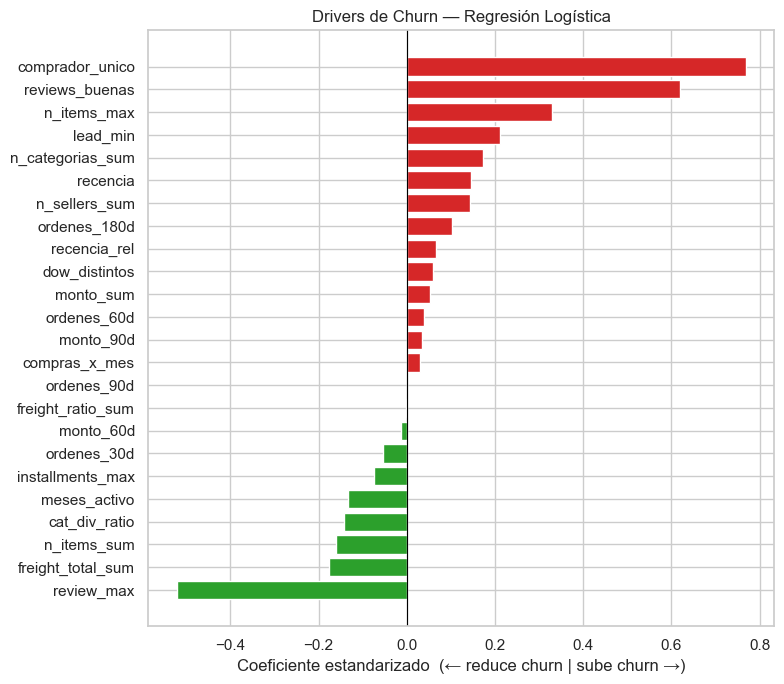

Gráfico guardado: drivers_churn_logreg.png


In [66]:
# =====================================================================
# GRÁFICO DE DRIVERS — coeficientes de la LogReg
# =====================================================================
import matplotlib.pyplot as plt

top = drivers.sort_values('coef')          # de más negativo (retención) a más positivo (churn)
colores = ['#2ca02c' if c < 0 else '#d62728' for c in top['coef']]

plt.figure(figsize=(8, 7))
plt.barh(top['feature'], top['coef'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente estandarizado  (← reduce churn | sube churn →)')
plt.title('Drivers de Churn — Regresión Logística')
plt.tight_layout()
plt.savefig(os.path.join(PATH, 'drivers_churn_logreg.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: drivers_churn_logreg.png")

In [67]:
print("len(SELECCION):", len(SELECCION))
print("SELECCION:", SELECCION)
# ¿Todas las de SELECCION existen en master_clean?
faltan = [f for f in SELECCION if f not in master_clean.columns]
print("Features de SELECCION que NO están en master_clean:", faltan)

len(SELECCION): 24
SELECCION: ['n_items_sum', 'n_categorias_sum', 'n_sellers_sum', 'compras_x_mes', 'recencia', 'comprador_unico', 'reviews_buenas', 'lead_min', 'freight_total_sum', 'ordenes_180d', 'monto_60d', 'ordenes_60d', 'review_max', 'ordenes_90d', 'recencia_rel', 'monto_sum', 'cat_div_ratio', 'freight_ratio_sum', 'ordenes_30d', 'monto_90d', 'installments_max', 'dow_distintos', 'meses_activo', 'n_items_max']
Features de SELECCION que NO están en master_clean: []


In [68]:
# ¿Qué feature de SELECCION no está en master (pero sí en master_clean)?
en_clean_no_en_master = [f for f in SELECCION if f in master_clean.columns and f not in master.columns]
print("Features en SELECCION que están en master_clean pero NO en master:", en_clean_no_en_master)

Features en SELECCION que están en master_clean pero NO en master: ['comprador_unico']


In [69]:
# =====================================================================
# TABLA DICCIONARIO — todas las variables con flagSelected e importancias
# =====================================================================
from sklearn.ensemble import RandomForestClassifier

# SELECCION_real: solo las features que existen (defensa contra desajustes)
SELECCION_real = [f for f in SELECCION if f in master_clean.columns]
print(f"SELECCION: {len(SELECCION)} declaradas | {len(SELECCION_real)} existen en master_clean")

# importancia_seleccion: del RF de selección, normalizada a % (suma exacta 100%)
tr_sel, _ = _tv(master_clean)
rf_sel = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=50,
                                max_features=0.5, class_weight='balanced_subsample',
                                n_jobs=-1, random_state=42)
rf_sel.fit(_sane(tr_sel[SELECCION_real]), tr_sel[TARGET])
imp_sel = pd.Series(rf_sel.feature_importances_, index=SELECCION_real)
imp_sel_pct = (imp_sel / imp_sel.sum() * 100).round(2)   # suma = 100% por construcción

# importancia_modelo_final: ranking por |coef| de la LogReg (1 = más importante)
imp_final = drivers.set_index('feature')['peso']
rank_final = imp_final.rank(ascending=False).astype(int)



# Construir la tabla con TODAS las variables
#todas_las_vars = [c for c in master.columns if c != 'rol']
todas_las_vars = [c for c in master_clean.columns if c != 'rol']
filas = []
for i, v in enumerate(todas_las_vars, start=1):
    if v == TARGET:
        dominio = 'Target'
    elif v == ID_COL or v == 'mes':
        dominio = 'Población Objetivo'
    else:
        dominio = 'Feature'
    seleccionada = 1 if v in SELECCION_real else 0
    #filas.append({
    #    'Nro': i,
    #    'Dominio': dominio,
    #    'Variable': v,
    #    'flagSelected': seleccionada,
    #    'importancia_seleccion_%': imp_sel_pct.get(v, 0.0) if seleccionada else 0.0,
    #    'importancia_modelo_final': int(rank_final.get(v, 0)) if seleccionada else 0,
    #})
    filas.append({
        'Nro': i,
        'Dominio': dominio,
        'Variable': v,
        'flagSelected': seleccionada,
        'importancia_seleccion_RF_%': imp_sel_pct.get(v, 0.0) if seleccionada else 0.0,
        'importancia_modelo_final_LogReg_rank': int(rank_final.get(v, 0)) if seleccionada else 0,
    })

tabla_diccionario = pd.DataFrame(filas)

pd.set_option('display.max_rows', None)
print(tabla_diccionario.to_string(index=False))
pd.reset_option('display.max_rows')

print(f"\nSeleccionadas: {tabla_diccionario['flagSelected'].sum()} de {len(tabla_diccionario)}")
print(f"Suma de importancia_seleccion: {tabla_diccionario['importancia_seleccion_RF_%'].sum():.1f}%")

tabla_diccionario.to_csv(os.path.join(PATH, 'diccionario_variables.csv'), index=False)
print("Guardado: diccionario_variables.csv")


SELECCION: 24 declaradas | 24 existen en master_clean
 Nro            Dominio           Variable  flagSelected  importancia_seleccion_RF_%  importancia_modelo_final_LogReg_rank
   1 Población Objetivo customer_unique_id             0                        0.00                                     0
   2 Población Objetivo                mes             0                        0.00                                     0
   3             Target           is_churn             0                        0.00                                     0
   4            Feature           recencia             1                        6.22                                     9
   5            Feature         antiguedad             0                        0.00                                     0
   6            Feature          frequency             0                        0.00                                     0
   7            Feature       meses_activo             1                        0.33 

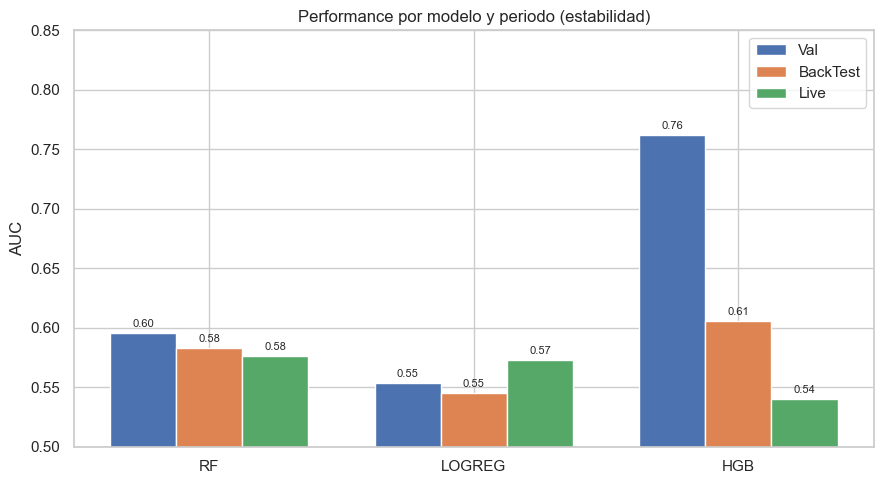

Guardado: performance_modelos.png


In [70]:
import matplotlib.pyplot as plt
import numpy as np

modelos = comparativa['modelo'].tolist()
x = np.arange(len(modelos))
ancho = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - ancho, comparativa['AUC_Val'],      ancho, label='Val')
ax.bar(x,         comparativa['AUC_BackTest'], ancho, label='BackTest')
ax.bar(x + ancho, comparativa['AUC_Live'],     ancho, label='Live')
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in modelos])
ax.set_ylabel('AUC'); ax.set_ylim(0.5, 0.85)
ax.set_title('Performance por modelo y periodo (estabilidad)')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
for i, m in enumerate(modelos):
    for j, col in enumerate(['AUC_Val','AUC_BackTest','AUC_Live']):
        ax.text(i + (j-1)*ancho, comparativa[col].iloc[i] + 0.005,
                f"{comparativa[col].iloc[i]:.2f}", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PATH, 'performance_modelos.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: performance_modelos.png")

In [71]:
# =====================================================================
# MÉTRICAS COMPLETAS del modelo final — precisión, recall, F1, AUC
# =====================================================================
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)

F = SELECCION
y_true = lv[TARGET]
y_proba = modelo_final.predict_proba(_sane(lv[F]))[:, 1]

# Umbral: con desbalance extremo, 0.5 no sirve. Usamos el umbral que maximiza F1.
from numpy import linspace
umbrales = linspace(0.1, 0.9, 81)
f1s = [f1_score(y_true, (y_proba >= u).astype(int), zero_division=0) for u in umbrales]
umbral_opt = umbrales[int(np.argmax(f1s))]

y_pred = (y_proba >= umbral_opt).astype(int)

print(f"=== MÉTRICAS EN LIVE (umbral óptimo F1 = {umbral_opt:.2f}) ===\n")
print(f"AUC      : {roc_auc_score(y_true, y_proba):.3f}")
print(f"Precisión: {precision_score(y_true, y_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.3f}")
print(f"F1-score : {f1_score(y_true, y_pred, zero_division=0):.3f}\n")

print("Matriz de confusión:")
cm = confusion_matrix(y_true, y_pred)
print(cm)
print("\nReporte completo:")
print(classification_report(y_true, y_pred, zero_division=0))

=== MÉTRICAS EN LIVE (umbral óptimo F1 = 0.10) ===

AUC      : 0.573
Precisión: 0.990
Recall   : 0.999
F1-score : 0.994

Matriz de confusión:
[[    0   277]
 [   23 26574]]

Reporte completo:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       277
           1       0.99      1.00      0.99     26597

    accuracy                           0.99     26874
   macro avg       0.49      0.50      0.50     26874
weighted avg       0.98      0.99      0.98     26874



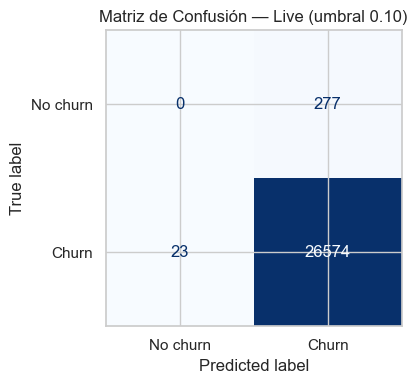

Guardado: matriz_confusion.png


In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión — Live (umbral {umbral_opt:.2f})')
plt.tight_layout()
plt.savefig(os.path.join(PATH, 'matriz_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: matriz_confusion.png")

In [73]:
# =====================================================================
# PASO 11 — Población objetivo + features del mes a predecir
#   (REUTILIZA generar_features: cero código nuevo)
# =====================================================================
# Mes a predecir = el siguiente al fin de los datos (2018-09)
T_pred = (df_master[DATE_COL].max().to_period('M') + 1).to_timestamp()
# T_pred = pd.Timestamp('2018-09-01')   # ← escribes el mes que quieras
print(f"Mes a predecir: {T_pred.date()}")

feat_pred = generar_features(df_ordenes, T_pred, VENTANA)   # misma fábrica, a fecha T_pred
print(f"Población a predecir: {len(feat_pred):,} clientes activos")

Mes a predecir: 2018-09-01
Población a predecir: 24,202 clientes activos


In [74]:
# =====================================================================
# PASO 12 — Master Table de predicción
# =====================================================================
master_pred = feat_pred.copy()          # mismas columnas que el panel de entrenamiento, sin target
print(f"master_pred: {master_pred.shape[0]:,} filas × "
      f"{len([c for c in master_pred.columns if c not in ['mes', ID_COL]])} features")
print(master_pred[['mes'] + [c for c in master_pred.columns if c not in ['mes', ID_COL]][:5]].head())

master_pred: 24,202 filas × 77 features
         mes  recencia  antiguedad  frequency  meses_activo  compras_x_mes
0 2018-09-01        38          38          1             1       0.789474
1 2018-09-01        23          23          1             1       1.000000
2 2018-09-01        85          85          1             1       0.352941
3 2018-09-01        37          37          1             1       0.810811
4 2018-09-01        85         694          2             2       0.086455


In [75]:
# Verficiación
import pickle, os
with open(os.path.join(PATH, 'modelo_churn.pkl'), 'rb') as fh:
    art = pickle.load(fh)
print("Modelo guardado:", type(art['modelo']).__name__)   # Pipeline si es LogReg
print("Nº features:", len(art['features']))
print("Tiene clean_params:", 'clean_params' in art)

Modelo guardado: Pipeline
Nº features: 24
Tiene clean_params: True


In [76]:
# =====================================================================
# PASO 13 — cleanMT + selección de variables sobre la tabla de predicción
#   (REUTILIZA clean_MT con los clean_params guardados: cero recálculo)
# =====================================================================
# Cargamos el artefacto entrenado (pickle del Paso 10)
with open(os.path.join(PATH, 'modelo_churn.pkl'), 'rb') as fh:
    artefacto = pickle.load(fh)

modelo       = artefacto['modelo']
F            = artefacto['features']        # las 15 features finales
clean_params = artefacto['clean_params']    # clip + medianas aprendidos en Train

# Mismas 77 features crudas que en entrenamiento (las que conocen los params)
pred_feat = list(clean_params['clip'].keys())

# Limpieza idéntica a la del entrenamiento (mismos clip y medianas)
master_pred_clean, _ = clean_MT(master_pred, pred_feat, params=clean_params)

# Selección final: nos quedamos con las 15 features del modelo
X_pred = _sane(master_pred_clean[F])
print(f"Tabla de predicción lista: {X_pred.shape[0]:,} clientes × {X_pred.shape[1]} features")

Tabla de predicción lista: 24,202 clientes × 24 features


In [77]:
# =====================================================================
# PASO 14 (versión autónoma) — cargar pickle y predecir desde cero
# Población de predcción, lo clientes activos en el último mes disponible
# =====================================================================
import pickle, os
with open(os.path.join(PATH, 'modelo_churn.pkl'), 'rb') as fh:
    artefacto = pickle.load(fh)

modelo       = artefacto['modelo']
F            = artefacto['features']
clean_params = artefacto['clean_params']

# limpiar la tabla de predicción con los MISMOS params del entrenamiento
pred_feat = list(clean_params['clip'].keys())
master_pred_clean, _ = clean_MT(master_pred, pred_feat, params=clean_params)

# predecir
X_pred = _sane(master_pred_clean[F])
proba  = modelo.predict_proba(X_pred)[:, 1]

predicciones = master_pred_clean[[ID_COL, 'mes']].copy()
predicciones['prob_churn'] = proba.round(4)
predicciones = predicciones.sort_values('prob_churn', ascending=False)
predicciones.to_csv(os.path.join(PATH, 'predicciones_churn.csv'), index=False)

print(f"{len(predicciones):,} predicciones guardadas en predicciones_churn.csv")
print(predicciones.head(10).to_string(index=False))

24,202 predicciones guardadas en predicciones_churn.csv
              customer_unique_id        mes  prob_churn
93ed318c43f54a2162e4377e7122ee0a 2018-09-01      0.9738
f700c475c69e4402aeaf4b55d531a2b2 2018-09-01      0.9726
19ec0b29446735170b035f6d2abcd667 2018-09-01      0.9720
e1708ec558c8c1d8bd5e24d022cd13ce 2018-09-01      0.9707
22e2a6909c8debb64e8560df49a25260 2018-09-01      0.9666
49e32d4f13ac76d97d32f1a6e2b37df4 2018-09-01      0.9659
60ca7b9a3d66cbc1568e81f3f8332c11 2018-09-01      0.9651
9f0f58c3c4a9fbfda6fd2aa4e1d8b51e 2018-09-01      0.9642
b57adba827f671c3f3f51139ce31f482 2018-09-01      0.9617
9906fc374d7fd8d7a8574dd27b1c0c0a 2018-09-01      0.9609
